# Tutorial for Active Learning, Bayesian Optimization, and Self-Driving Labs - Notebook 1

> **Note**: This notebook is shared as 'view-only' to ensure proper version control. While you are able to make changes to the code as you wish, these changes will not be saved to the primary version. We highly recommend that you make your own copy which will allow you to save any changes made on your own version. To accomplish this, go to File -> Save a Copy in Drive in the toolbar at the top of the page.
>
> We encourage readers to copy, modify, and use this code for their own projects. We ask that any publications which utilize this tutorial as a starting point to cite the accompanying article. This helps others also find this tutorial and use it as a resource for their own projects.
>
> Maroulis, A., Waynor, D., Gallagher, Q., Patel, R., Tamasi, M., Radford, D. C., Webb, M., & Gormley, A. (2025). A User's Guide to Your First Self-Driving Liquid Handling Lab. ChemRxiv, 2025(1023).
>
> https://doi.org/doi:10.26434/chemrxiv-2025-6ws9m
>
> This is Version 1.0.0, last updated on January 29th, 2026

## Overview

The goal of this tutorial is to walk through the essentials of **Active Learning (AL)** from start to finish, providing both conceptual explanations and hands-on code examples. A basic understanding of **Machine Learning (ML)** is assumed. If you're new to ML, we highly recommend reviewing:

- **A User's Guide to Machine Learning**: https://doi.org/10.1021/acspolymersau.2c00037  
- **Accompanying ML Colab notebook**: https://www.gormleylab.com/MLcolab

### Tutorial Overview

This guide is structured into three main notebooks, each building on the last:

---

>#### Tutorial Notebook 1: Principles of Active Learning  
>We begin with a simple, two-dimensional example of **Bayesian Optimization (BO)** applied to a black-box function. This notebook introduces the foundational concepts of active learning, including:  
>- Data seeding strategies
>- Fitting a surrogate model (e.g., Gaussian process, random forest, neural network) to observed data  
>- Using different acquisition functions to choose new sampling points

---

#### Tutorial Notebook 2: Application to Real-World Data - Self-Driving Labs

Here, we apply active learning to a **real experimental dataset** involving enzymes. This notebook demonstrates how active learning can be used to efficiently select informative experiments and accelerate discovery in scientific research. This notebook explores:

- Alternative data seeding strategies
- Structure of Self-Driving Labs
- Closing the Loop

## Tutorial Notebook 1: Principles of Active Learning
AL is a form of ML where an ML model "chooses" what data it is trained on. AL is employed to train maximally accurate ML models with minimal data or perform optimization of an unknown (i.e., black-box) function using minimal evaluations. For SDLs, AL workflows follow a general outline, the components of which are implemented in this notebook. For each component of the AL workflow, we provide implementations for different choices the user can make when conducting AL. Since we are optimizing a function, this tutorial is an implementation of BO.

<b>This notebook can be broken into the following outline:</b>
- 1.1 - Introduction to a black-box function
- 1.2 - Data seeding strategies
- 1.3 - Training a surrogate model
- 1.4 - Choosing new data with acquisition functions
- 1.5 - Doing an "Experiment" and updating the model
- 1.6 - Closing the AL/BO loop

#### Importing Packages

In [ ]:
!pip install kmedoids
import kmedoids
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF,ConstantKernel,DotProduct
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import norm

#### 1.1 - Introduction to a black-box function

When applying SDLs to a new problem, we perform measurements to gain an understanding of how a target property varies over a design space. Since we do not know anything about how our target property varies over the design space beforehand, we are attempting to characterize a <b>black-box function</b>. In the context of BO, we are performing <b>black-box optimization</b>, since we are trying to find optimal points on a function about which we have no prior knowledge.

To demonstrate BO in this notebook, we have chosen a simple function that will serve as our black-box function. We choose the Muller-Brown potential, a 2D function with multiple local minima commonly used to benchmark numerical methods in theoretical chemistry. We generate the function below by evaluating it on a set of discrete points which will serve as our design space. While we use the Muller-Brown potential in this notebook, the same workflow can be applied to different functions of any dimensionality.  

In [ ]:
def construct_muller_brown(n_points=100, cutoff=180):
    '''
        Constructs a Müller-Brown potential dataset with the specified number of
        points along each dimension. Because the Müller-Brown goes to infinity
        at large values of X_1 and X_2, we only include points for which the
        energy is below a specified cutoff.
    '''
    A = (-200, -100, -170, 15)
    a = (-1, -1, -6.7, 0.7)
    b = (0, 0, 11, 0.6)
    c = (-10, -10, -6.5, 0.7)
    x0 = (1, 0, -0.5, -1)
    y0 = (0, 0.5, 1.5, 1)

    x = np.linspace(-1.5, 1.2, n_points)
    y = np.linspace(-0.5, 2.0, n_points)
    X, Y = np.meshgrid(x, y)
    V = np.zeros(X.shape)
    for idx in range(4):
        t1 = a[idx] * (X - x0[idx]) ** 2
        t2 = b[idx] * (X - x0[idx]) * (Y - y0[idx])
        t3 = c[idx] * (Y - y0[idx]) ** 2
        V += A[idx] * np.exp(t1 + t2 + t3)

    V = V.reshape(-1)
    X = X.reshape(-1)
    Y = Y.reshape(-1)
    keep_idx = np.argwhere(V < cutoff).reshape(-1)
    X = X[keep_idx]
    Y = Y[keep_idx]
    V = V[keep_idx]
    V = V / np.max(V)

    return np.hstack((X.reshape(-1,1), Y.reshape(-1,1))), V.reshape(-1)

Global Minimum is -0.814 at (X₁, X₂) = (-0.55,1.44)


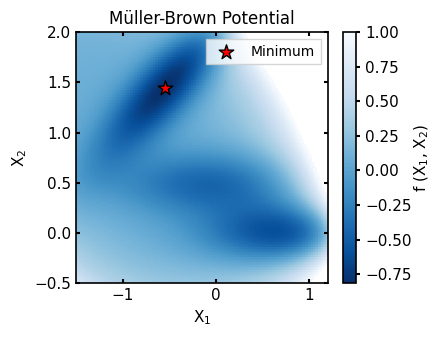

In [ ]:
# Get Müller-Brown (MB) potential.
domain, labels = construct_muller_brown()
vmin = np.min(labels)
vmax = np.max(labels)

# Find and plot global minimum location
min_idx = np.argmin(labels)
min_point = domain[min_idx]

# Print value of minimum (what we are optimizing for...)
print(f'Global Minimum is {np.round(vmin, 3)} at (X₁, X₂) = ({np.round(min_point[0], 2)},{np.round(min_point[1], 2)})')

# Visualize Müller-Brown potential and global minimum.
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['font.size'] = 11
fig, ax = plt.subplots(1,1,figsize=(4.5,3.5))
c = ax.scatter(domain[:,0], domain[:,1], s=4, c=labels, cmap='Blues_r', vmin=vmin, vmax=vmax)
ax.scatter(min_point[0], min_point[1], marker='*', color='red', edgecolor='black', s=120, zorder=3, label='Minimum')
ax.legend(loc='upper right', fontsize=10, fancybox=False)
ax.set_xlabel(r'X$_1$')
ax.set_ylabel(r'X$_2$')
ax.set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
ax.set_ylim(ymin=np.min(domain[:,1]), ymax=np.max(domain[:,1]))
ax.set_title('Müller-Brown Potential', fontsize=12)
ax.tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)
cbar = plt.colorbar(c)
cbar.set_label(r'f (X$_1$, X$_2$)', labelpad=1)
cbar.ax.tick_params(width=1.5, length=3.0)
plt.tight_layout()
plt.show()

#### 1.2 - Data-seeding strategies

AL/BO loops choose new points to measure based on previously acquired data. Therefore, to begin an AL/BO loop, an initial dataset must be created. When applying BO to a black-box function, no knowledge about the function is known beforehand, so initial datasets are constructed based on the structure of the design space. Examples of sampling algorithms used to construct initial datasets include:
- <b>Random sampling</b>, where points are chosen randomly from the design space.
- <b>Furthest point sampling</b>, where points are sequentially chosen by choosing the points which is furthest from all previously chosen points. Such samples are also referred to as maximin designs.
- <b>Cluster-based sampling</b>, where points are chosen to minimize the average distance of any point in the design space to its nearest selected point. Such samples are similar to the centroids of the <i>k</i>-means clustering algorithm.

Below, we provide implementations of these three sampling algorithms. You can modify which sampling algorithm is used in this BO notebook by specifying the appropriate string for the `SAMPLER` variable. We also provide a visualization of all sampling algorithms applied to the Muller-Brown potential.

As a note, the three sampling algorithms considered here are a subset of those commonly used for AL/BO applications. Other examples include maximum entropy sampling, Latin hypercube sampling, Sobol sampling, etc. The optimal choice of sampler for data seeding in AL/BO workflows depends on the problem and is an active area of research.

In [ ]:
SAMPLER = 'random' # Options include: 'random', 'maximin', and 'cluster'.

In [ ]:
def random_sample(X, num=10, seed=1):
  np.random.seed(seed)
  idx = [i for i in range(X.shape[0])]
  np.random.shuffle(idx)
  sample_idx = idx[0:num]
  return sample_idx

def maximin_sample(X, num=10, seed=1):
  X_sc = MinMaxScaler().fit_transform(X)
  np.random.seed(1)
  start_idx = np.random.randint(low=0, high=X_sc.shape[0], size=1).item()
  sample_idx = [start_idx]
  for _ in range(num - 1):
    chosen_points = X_sc[sample_idx].reshape(-1,2)
    distances = cdist(chosen_points, X_sc)
    distances = np.min(distances, axis=0).reshape(-1,1)
    new_idx = np.argmax(distances, axis=0).item()
    sample_idx.append(new_idx)
  return sample_idx

def cluster_sample(X, num=10, seed=1):
  X_sc = MinMaxScaler().fit_transform(X)
  diss = squareform(pdist(domain))
  k = kmedoids.fasterpam(diss, num, max_iter=100, random_state=seed)
  sample_idx = k.medoids.tolist()
  return sample_idx

def sample(sampler, X, num, seed):
  if sampler == 'random':
    return random_sample(X, num, seed)
  elif sampler == 'maximin':
    return maximin_sample(X, num, seed)
  elif sampler == 'cluster':
    return cluster_sample(X, num, seed)

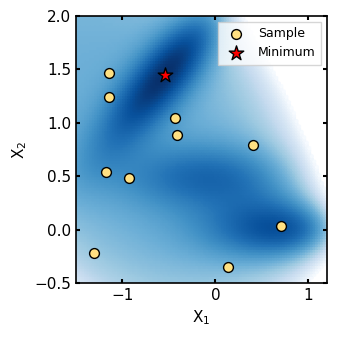

In [ ]:
# Perform data seeding using the method specified by SAMPLER.
sample_idx = sample(sampler=SAMPLER, X=domain, num=10, seed=1)

# Visualize chosen sample.
fig, ax = plt.subplots(1,1,figsize=(3.5,3.5))
ax.scatter(domain[:,0], domain[:,1], s=4, c=labels, cmap='Blues_r', vmin=vmin, vmax=vmax)
ax.scatter(domain[sample_idx,0], domain[sample_idx,1], s=50, color='#FFE082', edgecolor='black', zorder=6, label='Sample', clip_on=False)
ax.scatter(min_point[0], min_point[1], marker='*', color='red', edgecolor='black', s=120, zorder=3, label='Minimum')
ax.legend(loc='upper right', fontsize=9, fancybox=False)
ax.set_xlabel(r'X$_1$')
ax.set_ylabel(r'X$_2$')
ax.set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
ax.set_ylim(ymin=np.min(domain[:,1]), ymax=np.max(domain[:,1]))
ax.tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)
plt.tight_layout()
plt.show()

In [ ]:
# Make samples using each implemented strategy.
random_idx = sample(sampler='random', X=domain, num=10, seed=1)
maximin_idx = sample(sampler='maximin', X=domain, num=10, seed=1)
cluster_idx = sample(sampler='cluster', X=domain, num=10, seed=1)

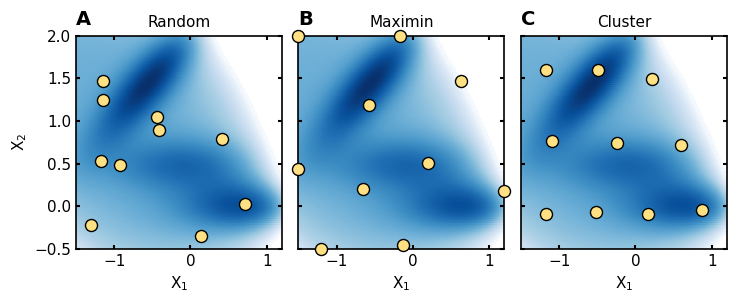

In [ ]:
# Visualize alternative seeding approaches applied to Muller-Brown function.
fig, axs = plt.subplots(1,3,figsize=(7.5, 3.2), sharey=True)
axs[0].scatter(domain[:,0], domain[:,1], s=4, c=labels, cmap='Blues_r', vmin=vmin, vmax=vmax)
axs[1].scatter(domain[:,0], domain[:,1], s=4, c=labels, cmap='Blues_r', vmin=vmin, vmax=vmax)
axs[2].scatter(domain[:,0], domain[:,1], s=4, c=labels, cmap='Blues_r', vmin=vmin, vmax=vmax)
axs[0].scatter(domain[random_idx,0], domain[random_idx,1], s=75, color='#FFE082', edgecolor='black', zorder=6, clip_on=False)
axs[1].scatter(domain[maximin_idx,0], domain[maximin_idx,1], s=75, color='#FFE082', edgecolor='black', zorder=6, clip_on=False)
axs[2].scatter(domain[cluster_idx,0], domain[cluster_idx,1], s=75, color='#FFE082', edgecolor='black', zorder=6, clip_on=False)
axs[0].set_title('Random', fontsize=11)
axs[1].set_title('Maximin', fontsize=11)
axs[2].set_title('Cluster', fontsize=11)
axs[0].set_ylabel(r'X$_2$')
axs[0].set_ylim(ymin=np.min(domain[:,1]), ymax=np.max(domain[:,1]))
for idx in [0, 1, 2]:
  axs[idx].set_xlabel(r'X$_1$')
  axs[idx].set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
  axs[idx].tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)

axs[0].text(
    0.0, 1.12, 'A', transform=axs[0].transAxes, fontsize=14,
    fontweight='bold', va='top', ha='left'
)
axs[1].text(
    0.0, 1.12, 'B', transform=axs[1].transAxes, fontsize=14,
    fontweight='bold', va='top', ha='left'
)
axs[2].text(
    0.0, 1.12, 'C', transform=axs[2].transAxes, fontsize=14,
    fontweight='bold', va='top', ha='left'
)

plt.tight_layout()
plt.savefig('./seeding.pdf')
plt.show()

#### 1.3 - Training a Surrogate Model

After points have been selected by a data seeding algorithm, these points are measured by the SDL. This produces an initial dataset that can be used for ML model training. Since the ML model is being trained to reproduce the target property for experimental inputs, it is referred to as a <b>surrogate model</b>, since it serves as a <i>surrogate</i> for the actual experiment to be performed.

As with data seeding, there are several options for the type of ML model to use as a surrogate model, and there is no universally correct answer. Some examples include:
- <b>Gaussian process</b> (GP), a kernel-based ML model commonly used for implementations of BO.
- <b>Random forest</b> (RF), a tree-based ML model often used as an alternative to GPs for BO, especially in high-dimensional settings.
- <b>Neural network</b> (NN), a deep learning-based ML model that performs very well for large dataset sizes (i.e., generally 1,000+ measurements).

In the context of BO, we want to use our model to guide the selection of new measurements that are likely to improve upon previous measurements. Therefore, it is helpful to not only make predictions on the rest of the design space, but to also assess the uncertainty of our ML model when making predictions. We implement GPs, RFs, and NNs in a manner that allows for both predictions and uncertainties to be made on unlabeled points.

You can choose the model to use for BO by specifying the `MODEL` parameter. Additionally, we show the predictions and uncertainties of each model choice trained on the initial sample chosen above to give you a sense for how these models differ in the nature of their predictions.

In [ ]:
MODEL = 'gp' # Options include 'gp', 'rf', and 'nn'.

In [ ]:
class GP:
  '''
    Wrapper for sklearn's GP implementation compatible with a flexible BO
    implementation. This GP uses an isotropic radial basis function kernel.
    Inputs and labels are scaled using a Standard scaler.
  '''
  def __init__(self):
    self.name = 'gp'

  def fit(self, X, y):
    self.x_scaler = StandardScaler()
    self.x_scaler.fit(X)
    self.y_scaler = StandardScaler()
    self.y_scaler.fit(y.reshape(-1,1))
    X_sc = self.x_scaler.transform(X)
    y_sc = self.y_scaler.transform(y.reshape(-1,1)).reshape(-1)
    self.model = GaussianProcessRegressor(
        kernel=RBF(length_scale_bounds=(0.1, 10.0))
    )
    self.model.fit(X_sc, y_sc)

  def predict(self, X, scale=True):
    X_sc = self.x_scaler.transform(X)
    y_sc_pred = self.model.predict(X_sc)
    if scale:
      y_pred = self.y_scaler.inverse_transform(y_sc_pred.reshape(-1,1))
      return y_pred.reshape(-1)
    else:
      return y_sc_pred.reshape(-1)

  def uncertainty(self, X):
    X_sc = self.x_scaler.transform(X)
    _, y_sc_std = self.model.predict(X_sc, return_std=True)
    return y_sc_std.reshape(-1)

class RF:
  '''
    Wrapper for sklearn's RF implementation compatible with a flexible BO
    implementation. Uncertainties are computed using the standard deviation
    of individual decision tree predictions.
  '''
  def __init__(self, n_estimators=300):
    self.name = 'rf'
    self.n_estimators = n_estimators

  def fit(self, X, y):
    self.model = RandomForestRegressor(n_estimators=self.n_estimators)
    self.model.fit(X, y)

  def predict(self, X, scale=True):
    return self.model.predict(X)

  def uncertainty(self, X):
    y_pred = np.array([t.predict(X) for t in self.model.estimators_])
    y_std = np.std(y_pred, axis=0)
    return y_std

class NN:
  '''
    Wrapper for sklearn's NN implementation compatible with flexible BO
    implementation. Uncertainties are computed using the standard deviation
    of predictions from an ensemble of NN models. Inputs and labels are scaled
    using the Standard scaler. All NNs have two hidden layers of size 100 and
    are optimized using the L-BFGS optimizer.
  '''
  def __init__(self, n_models=10):
    self.name = 'nn'
    self.models = [
        MLPRegressor(
            hidden_layer_sizes=(100,100),
            solver='lbfgs',
            random_state=i
        ) for i in range(n_models)
    ]

  def fit(self, X, y):
    self.x_scaler = StandardScaler()
    self.x_scaler.fit(X)
    self.y_scaler = StandardScaler()
    self.y_scaler.fit(y.reshape(-1,1))
    X_sc = self.x_scaler.transform(X)
    y_sc = self.y_scaler.transform(y.reshape(-1,1)).reshape(-1)
    for model in self.models:
        model.fit(X_sc, y_sc)

  def predict(self, X, scale=True):
    X_sc = self.x_scaler.transform(X)
    y_sc_pred = np.array([model.predict(X_sc) for model in self.models])
    y_sc_pred = np.mean(y_sc_pred, axis=0)
    if scale:
      y_pred = self.y_scaler.inverse_transform(y_sc_pred.reshape(-1,1))
      return y_pred.reshape(-1)
    else:
      return y_sc_pred.reshape(-1)

  def uncertainty(self, X):
    X_sc = self.x_scaler.transform(X)
    y_sc_pred = np.array([model.predict(X_sc) for model in self.models])
    y_sc_std = np.std(y_sc_pred, axis=0).reshape(-1)
    return y_sc_std.reshape(-1)

def get_model(model_name):
  if model_name == 'gp':
    return GP()
  if model_name == 'rf':
    return RF(n_estimators=300)
  if model_name == 'nn':
    return NN(n_models=10)

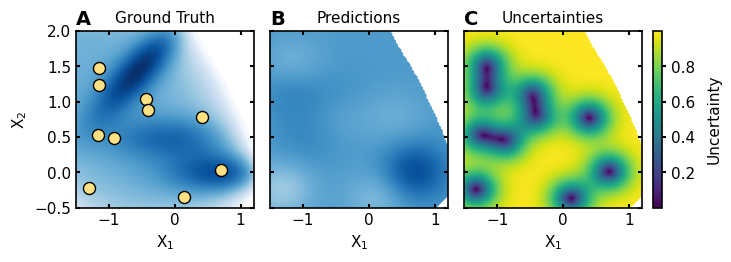

In [ ]:
# Train surrogate model on initial data sample.
model = get_model(MODEL)
model.fit(domain[sample_idx], labels[sample_idx])

# Get predictions and uncertainties on entire design space.
y_pred = model.predict(domain)
y_std = model.uncertainty(domain)

# Visualize predictions and uncertainties on entire design space.
fig, axs = plt.subplots(1,3,figsize=(7.5, 2.8), sharey=True, gridspec_kw={'width_ratios':[1,1,1.25]})
axs[0].scatter(domain[:,0], domain[:,1], s=4, c=labels, cmap='Blues_r', vmin=vmin, vmax=vmax)
axs[1].scatter(domain[:,0], domain[:,1], s=4, c=y_pred, cmap='Blues_r', vmin=vmin, vmax=vmax)
c = axs[2].scatter(domain[:,0], domain[:,1], s=4, c=y_std, cmap='viridis')
axs[0].scatter(domain[sample_idx,0], domain[sample_idx,1], s=75, color='#FFE082', edgecolor='black', zorder=6, clip_on=False)
axs[0].set_title('Ground Truth', fontsize=11)
axs[1].set_title('Predictions', fontsize=11)
axs[2].set_title('Uncertainties', fontsize=11)
axs[0].set_ylabel(r'X$_2$')
axs[0].set_ylim(ymin=np.min(domain[:,1]), ymax=np.max(domain[:,1]))
for idx in [0, 1, 2]:
  axs[idx].set_xlabel(r'X$_1$')
  axs[idx].set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
  axs[idx].tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)
cbar = plt.colorbar(c)
cbar.set_label(r'Uncertainty', labelpad=8.0)
cbar.ax.tick_params(width=1.5, length=3)

axs[0].text(
    0.0, 1.12, 'A', transform=axs[0].transAxes, fontsize=14,
    fontweight='bold', va='top', ha='left'
)
axs[1].text(
    0.0, 1.12, 'B', transform=axs[1].transAxes, fontsize=14,
    fontweight='bold', va='top', ha='left'
)
axs[2].text(
    0.0, 1.12, 'C', transform=axs[2].transAxes, fontsize=14,
    fontweight='bold', va='top', ha='left'
)

plt.tight_layout()
plt.savefig('./surrogate.pdf')
plt.show()

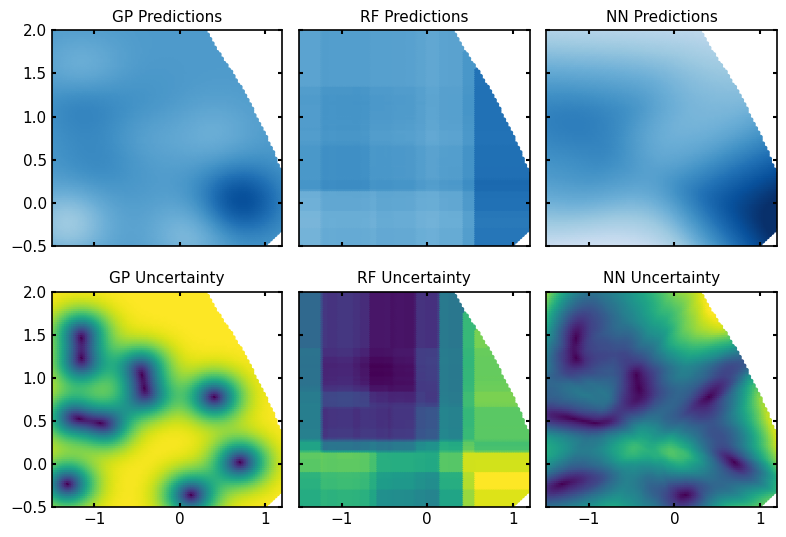

In [ ]:
# Visualize predictions and uncertainties produced from each choice of
# surrogate model.
gp = get_model('gp')
gp.fit(domain[sample_idx], labels[sample_idx])
y_gp = gp.predict(domain)
y_std_gp = gp.uncertainty(domain)
rf = get_model('rf')
rf.fit(domain[sample_idx], labels[sample_idx])
y_rf = rf.predict(domain)
y_std_rf = rf.uncertainty(domain)
nn = get_model('nn')
nn.fit(domain[sample_idx], labels[sample_idx])
y_nn = nn.predict(domain)
y_std_nn = nn.uncertainty(domain)

# Visualize predictions and uncertainties on entire design space.
fig, axs = plt.subplots(2,3,figsize=(8, 5.5), sharex=True, sharey=True, gridspec_kw={'width_ratios':[1,1,1]})
axs[0,0].scatter(domain[:,0], domain[:,1], s=4, c=y_gp, cmap='Blues_r', vmin=vmin, vmax=vmax)
axs[1,0].scatter(domain[:,0], domain[:,1], s=4, c=y_std_gp, cmap='viridis')
axs[0,1].scatter(domain[:,0], domain[:,1], s=4, c=y_rf, cmap='Blues_r', vmin=vmin, vmax=vmax)
axs[1,1].scatter(domain[:,0], domain[:,1], s=4, c=y_std_rf, cmap='viridis')
axs[0,2].scatter(domain[:,0], domain[:,1], s=4, c=y_nn, cmap='Blues_r', vmin=vmin, vmax=vmax)
axs[1,2].scatter(domain[:,0], domain[:,1], s=4, c=y_std_nn, cmap='viridis')

axs[0,0].set_title('GP Predictions', fontsize=11)
axs[1,0].set_title('GP Uncertainty', fontsize=11)
axs[0,1].set_title('RF Predictions', fontsize=11)
axs[1,1].set_title('RF Uncertainty', fontsize=11)
axs[0,2].set_title('NN Predictions', fontsize=11)
axs[1,2].set_title('NN Uncertainty', fontsize=11)

for i1 in [0, 1]:
  for i2 in [0, 1, 2]:
    axs[i1,i2].set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
    axs[i1,i2].set_ylim(ymin=np.min(domain[:,1]), ymax=np.max(domain[:,1]))
    axs[i1,i2].tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)

plt.tight_layout()
plt.show()

#### 1.4 - Acquiring New Data

Once a surrogate model has been trained, our surrogate model provides an estimate of the target property and the uncertainty of its estimate at every point in the design space. To decide what new measurements to make, we can define an <b>acquisition function</b> over our design space, which is a function of predictions and uncertainties that we would like to maximize by choosing a new point. As with the previous sections, there are different kinds of acquisition functions that can be used to perform BO. Some common examples include:

- <b>Upper / lower confidence bound</b> (U/LCB), a simple sum of predictions and uncertainties. UCB is used for maximization, while LCB is used for minimization. We are trying to minimize the Muller-Brown potential, so we use LCB in this tutorial.
- <b>Probability improvement</b> (PI), which computes the probability that a new measurement will improve over the current best sample.
- <b>Expected improvement</b> (EI), which computes, in expectation, the magnitude of improvement over the current best sample.

As you might expect, there are many other acquisition functions used in literature that vary based on different priorities or practical considerations. For example, when one is concerned with characterizing a function instead of optimizing it (i.e., AL but not BO), the only change is to use an uncertainty-based acquisition function. The optimal choice of acquisition function depends on your problem and is an active area of research.

When optimizing a black-box function, there are two considerations to make. First, you would like to make measurements in unexplored regions of the design space to locate unidentified optima—in other words, you'd like to <b>explore</b> the design space. Second, you would like to make measurements near previous measurements that have performed well—in other words, you'd like to <b>exploit</b> prior data. Effective black-box optimization must navigate this <b>exploration-exploitation tradeoff</b> to find global optima with minimal evaluations. All of the acquisition functions listed above contain parameters that balance the extent to which exploration or exploitation is prioritized. In this implementation, we have fixed these parameters, but we encourage you to explore how modifying these values impacts BO performance.

You can specify the acquisition function you'd like to use using the `ACQUISITION` variable below. We also visualize the different acquisition functions below to give you a sense of how LCB, PI, and EI vary based on the data seeding strategy and surrogate model choices you've made above.

In [ ]:
ACQUISITION = 'lcb' # Options include 'lcb', 'pi', and 'ei'.

In [ ]:
def lower_confidence_bound(y_pred, y_std, param=1.0):
  return -(y_pred - param * y_std)

def probability_of_improvement(y_pred, y_std, y_best, param=0.0):
  z = (y_best - y_pred - param) / y_std
  pi = norm.cdf(z)
  return pi

def expected_improvement(y_pred, y_std, y_best, param=0.0):
  z = (y_best - y_pred - param) / y_std
  ei = (y_best - y_pred - param) * norm.cdf(z) + y_std * norm.pdf(z)
  return ei

def compute_acquisition_function(acq, y_pred, y_std, y_best):
  if acq == 'lcb':
    return lower_confidence_bound(y_pred, y_std)
  if acq == 'pi':
    return probability_of_improvement(y_pred, y_std, y_best)
  if acq == 'ei':
    return expected_improvement(y_pred, y_std, y_best)

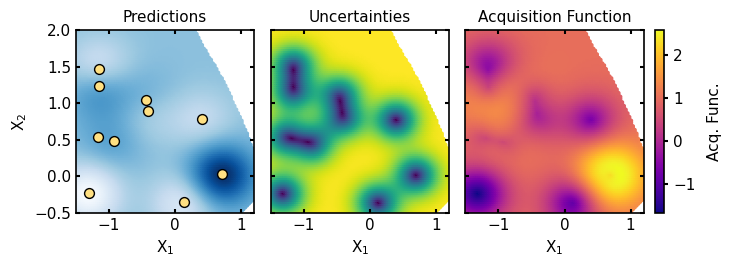

In [ ]:
# Compute acquisition function for current data and surrogate.
y_best = np.min(labels[sample_idx])
y_pred = model.predict(domain, scale=False)
y_std = model.uncertainty(domain)
acq_fn = compute_acquisition_function(ACQUISITION, y_pred, y_std, y_best)

# Visualize current predictions, uncertainties, and acquisition function for
# current data and surrogate.
fig, axs = plt.subplots(1,3,figsize=(7.5, 2.8), sharey=True, gridspec_kw={'width_ratios':[1,1,1.25]})
axs[0].scatter(domain[:,0], domain[:,1], s=4, c=y_pred, cmap='Blues_r')
axs[1].scatter(domain[:,0], domain[:,1], s=4, c=y_std, cmap='viridis')
c = axs[2].scatter(domain[:,0], domain[:,1], s=4, c=acq_fn, cmap='plasma')
axs[0].scatter(domain[sample_idx,0], domain[sample_idx,1], s=50, color='#FFE082', edgecolor='black', zorder=6, clip_on=False)
axs[0].set_title('Predictions', fontsize=11)
axs[1].set_title('Uncertainties', fontsize=11)
axs[2].set_title('Acquisition Function', fontsize=11)
axs[0].set_ylabel(r'X$_2$')
axs[0].set_ylim(ymin=np.min(domain[:,1]), ymax=np.max(domain[:,1]))
for idx in [0, 1, 2]:
  axs[idx].set_xlabel(r'X$_1$')
  axs[idx].set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
  axs[idx].tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)
cbar = plt.colorbar(c)
cbar.set_label(r'Acq. Func.', labelpad=8.0)
cbar.ax.tick_params(width=1.5, length=3)
plt.tight_layout()
plt.show()

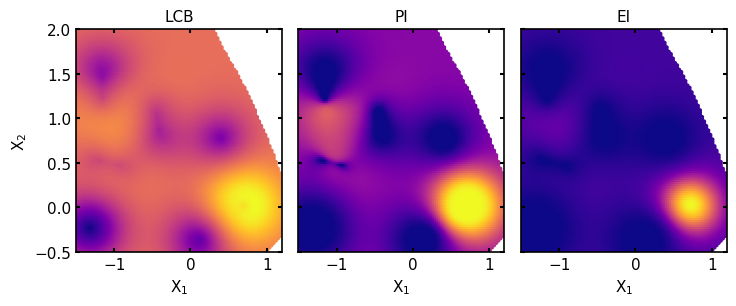

In [ ]:
# Visualize all acquisition functions for current data and surrogate.
lcb_fn = compute_acquisition_function('lcb', y_pred, y_std, y_best)
pi_fn = compute_acquisition_function('pi', y_pred, y_std, y_best)
ei_fn = compute_acquisition_function('ei', y_pred, y_std, y_best)
fig, axs = plt.subplots(1,3,figsize=(7.5, 3.2), sharey=True, gridspec_kw={'width_ratios':[1,1,1]})
axs[0].scatter(domain[:,0], domain[:,1], s=4, c=lcb_fn, cmap='plasma')
axs[1].scatter(domain[:,0], domain[:,1], s=4, c=pi_fn, cmap='plasma')
c = axs[2].scatter(domain[:,0], domain[:,1], s=4, c=ei_fn, cmap='plasma')
axs[0].set_title('LCB', fontsize=11)
axs[1].set_title('PI', fontsize=11)
axs[2].set_title('EI', fontsize=11)
axs[0].set_ylabel(r'X$_2$')
axs[0].set_ylim(ymin=np.min(domain[:,1]), ymax=np.max(domain[:,1]))
for idx in [0, 1, 2]:
  axs[idx].set_xlabel(r'X$_1$')
  axs[idx].set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
  axs[idx].tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)

plt.tight_layout()
plt.show()

#### 1.5 - Doing an "Experiment" and updating the model

Once the acquisition function has been defined on our design space, our next measurement is selected by choosing the point which maximizes our acquisition function. This set of inputs is submitted to our SDL to be measured via experiment.

We plot the value chosen by our choice of data, surrogate model, and acquisition function below.

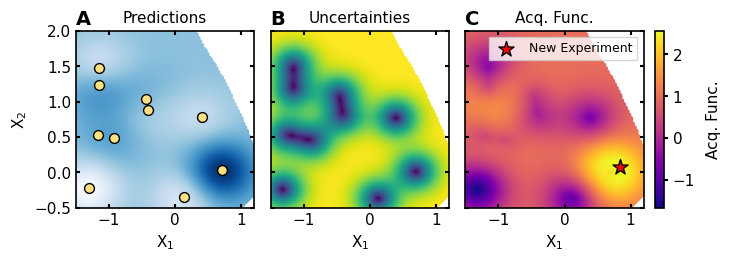

In [ ]:
# Get new experiment.
new_idx = np.argmax(acq_fn).item()

# Visualize current predictions, uncertainties, and acquisition function for
# current data and surrogate.
fig, axs = plt.subplots(1,3,figsize=(7.5, 2.8), sharey=True, gridspec_kw={'width_ratios':[1,1,1.25]})
axs[0].scatter(domain[:,0], domain[:,1], s=4, c=y_pred, cmap='Blues_r')
axs[1].scatter(domain[:,0], domain[:,1], s=4, c=y_std, cmap='viridis')
c = axs[2].scatter(domain[:,0], domain[:,1], s=4, c=acq_fn, cmap='plasma')
axs[2].scatter(domain[new_idx,0], domain[new_idx,1], s=130, marker='*', edgecolor='black', color='red', label='New Experiment')
axs[0].scatter(domain[sample_idx,0], domain[sample_idx,1], s=50, color='#FFE082', edgecolor='black', zorder=6, clip_on=False)
axs[0].set_title('Predictions', fontsize=11)
axs[1].set_title('Uncertainties', fontsize=11)
axs[2].set_title('Acq. Func.', fontsize=11)
axs[0].set_ylabel(r'X$_2$')
axs[0].set_ylim(ymin=np.min(domain[:,1]), ymax=np.max(domain[:,1]))
for idx in [0, 1, 2]:
  axs[idx].set_xlabel(r'X$_1$')
  axs[idx].set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
  axs[idx].tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)
cbar = plt.colorbar(c)
cbar.set_label(r'Acq. Func.', labelpad=8.0)
cbar.ax.tick_params(width=1.5, length=3)
axs[2].legend(fancybox=False, fontsize=9)

axs[0].text(
    0.0, 1.12, 'A', transform=axs[0].transAxes, fontsize=14,
    fontweight='bold', va='top', ha='left'
)
axs[1].text(
    0.0, 1.12, 'B', transform=axs[1].transAxes, fontsize=14,
    fontweight='bold', va='top', ha='left'
)
axs[2].text(
    0.0, 1.12, 'C', transform=axs[2].transAxes, fontsize=14,
    fontweight='bold', va='top', ha='left'
)

plt.tight_layout()
plt.savefig('acquisition.pdf')
plt.show()

#### 1.6 - Closing the AL/BO loop

By measuring the point which maximizes the acquisition function, we have acquired new data. This puts us at the same step in the AL/BO process that we were at after data seeding. That is, we can retrain our surrogate model on our modified dataset, compute predictions and uncertainties on the design space, compute the acquisition function over the design space, and then select a new experiment which maximizes our acquisition function. Doing so would close the AL/BO loop by recommending experiments without human intervension—the ultimate goal of employing AL/BO for SDLs.

To demonstrate how this process would work autonomously, we perform more steps of the current AL/BO workflow in a loop. We visualize how model predictions, uncertainties, and the acquisition function changes as new experiments are run.

Round: 1, Current minimum: -0.589
Round: 2, Current minimum: -0.589
Round: 3, Current minimum: -0.589


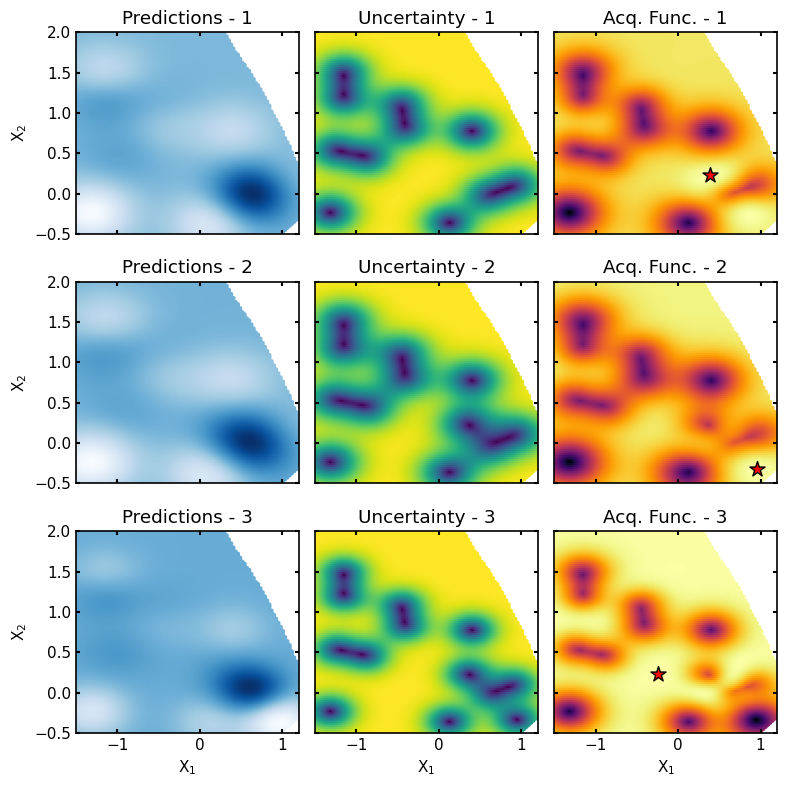

In [ ]:
# Add new measurement to training data.
sample_idx.append(new_idx)

# VISUALIZATION ONLY: Prepare BO visualization.
fig, axs = plt.subplots(3, 3, figsize=(8,8), sharey=True, sharex=True)

# Automate three more iterations of BO.
for iteration in range(3):

  # Train a new surrogate model.
  model = get_model(MODEL)
  model.fit(domain[sample_idx], labels[sample_idx])
  y_pred = model.predict(domain, scale=True)
  y_std = model.uncertainty(domain)

  # Compute the acquisition function.
  y_best = np.min(labels[sample_idx])
  acq_fn = compute_acquisition_function(ACQUISITION, y_pred, y_std, y_best)

  # Choose a new point.
  new_idx = np.argmax(acq_fn).item()

  # VISUALIZATION ONLY: Visualize changes in predictions, uncertainties, and acquisition function.
  axs[iteration,0].scatter(domain[:,0], domain[:,1], c=y_pred, cmap=plt.get_cmap('Blues_r'), s=4)
  axs[iteration,1].scatter(domain[:,0], domain[:,1], c=y_std, cmap=plt.get_cmap('viridis'), s=4)
  axs[iteration,2].scatter(domain[:,0], domain[:,1], c=acq_fn, cmap=plt.get_cmap('inferno'), s=4)
  axs[iteration,2].scatter(domain[new_idx,0], domain[new_idx,1], s=130, marker='*', edgecolor='black', color='red', zorder=6, clip_on=False)
  axs[iteration,0].set_ylabel(r'X$_2$')
  axs[iteration,0].set_ylim(ymin=np.min(domain[:,1]), ymax=np.max(domain[:,1]))
  axs[iteration,0].tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)
  axs[iteration,1].tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)
  axs[iteration,2].tick_params(axis='both', left=True, right=True, top=True, bottom=True, direction='in', width=1.5, length=3)
  axs[iteration,0].set_title(f'Predictions - {iteration + 1}')
  axs[iteration,1].set_title(f'Uncertainty - {iteration + 1}')
  axs[iteration,2].set_title(f'Acq. Func. - {iteration + 1}')

  # Add new point.
  sample_idx.append(new_idx)

  # Report current optimization performance.
  print(f'Round: {iteration + 1}, Current minimum: {y_best:.3f}')

# VISUALIZATION ONLY: Prepare final visualization.
axs[-1,0].set_xlabel(r'X$_1$')
axs[iteration,0].set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
axs[-1,1].set_xlabel(r'X$_1$')
axs[iteration,1].set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
axs[-1,2].set_xlabel(r'X$_1$')
axs[iteration,2].set_xlim(xmin=np.min(domain[:,0]), xmax=np.max(domain[:,0]))
plt.tight_layout()
plt.show()


Using our autonomous setup, we then benchmark how different choices of data seeding strategy, surrogate model, and acquisition function perform on the optimization of the Müller-Brown potential. Below, we allow you to specify the parameters of three different BO algorithms and the number of points these BO algorithms should acquire. We then plot the optimization performance of these algorithms. Which algorithms perform best and why? We encourage you to understand how different design choices impact BO performance on this task.

In [ ]:
# Specify algorithms for BO benchmarking on Muller-Brown dataset.
BO_ALGORITHMS = [
    ['random', 'gp', 'ei'],
    ['maximin', 'rf', 'lcb'],
    ['cluster', 'nn', 'pi']
]
N_SEED = 10
N_POINTS = 40

In [ ]:
# Benchmark algorithms on Muller-Brown dataset.
performances = []
for algo_idx, ALGO in enumerate(BO_ALGORITHMS):
  print(f'Running BO for algorithm {algo_idx + 1} / {len(BO_ALGORITHMS)}...')
  performance = []

  # Step 0: Data seeding.
  chosen_idx = sample(sampler=ALGO[0], X=domain, num=N_SEED, seed=1)

  # Begin AL/BO loop.
  for iteration in range(N_POINTS):

    # Step 1: Surrogate model training.
    model = get_model(ALGO[1])
    model.fit(domain[chosen_idx], labels[chosen_idx])
    y_pred = model.predict(domain, scale=True)
    y_std = model.uncertainty(domain)
    y_best = np.min(labels[chosen_idx])

    # Step 2: Compute acquisition function.
    acq_fn = compute_acquisition_function(ALGO[2], y_pred, y_std, y_best)

    # Step 3: Choose new point to measure.
    new_idx = np.argmax(acq_fn).item()
    chosen_idx.append(new_idx)

    # Measure algorithm performance by keeping track of current minimum.
    performance.append(y_best)

    # Check for early stoppage.
    if y_best <= np.min(labels):
      print(f'Global minimum found after {iteration + 1} rounds!')
      break

  # Save performance of this algorithm.
  performances.append(performance)

  # Report if global minimum not found.
  if np.min(performance) != np.min(labels):
    print(f'Global minimum NOT found after {N_POINTS + 1} rounds!')

Running BO for algorithm 1 / 3...
Global minimum found after 30 rounds!
Running BO for algorithm 2 / 3...
Running BO for algorithm 3 / 3...
Global minimum found after 19 rounds!


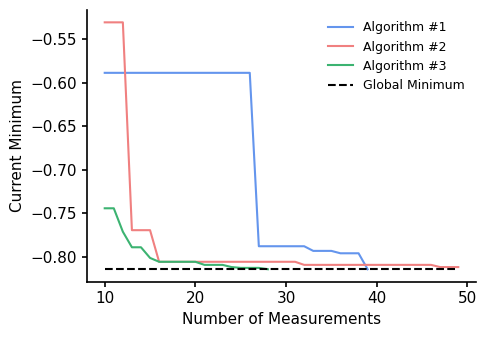

In [ ]:
# Plot results of BO benchmarking on Muller-Brown dataset.
fig, ax = plt.subplots(1,1,figsize=(5.0,3.5))
ax.plot([i + N_SEED for i in range(len(performances[0]))], performances[0], label='Algorithm #1', color='cornflowerblue')
ax.plot([i + N_SEED for i in range(len(performances[1]))], performances[1], label='Algorithm #2', color='lightcoral')
ax.plot([i + N_SEED for i in range(len(performances[2]))], performances[2], label='Algorithm #3', color='mediumseagreen')
ax.plot([i + N_SEED for i in range(N_POINTS)], [np.min(labels) for _ in range(N_POINTS)], linestyle='dashed', color='black', label='Global Minimum', zorder=2)
ax.set_xlabel('Number of Measurements')
ax.set_ylabel('Current Minimum')
ax.tick_params(axis='both', left=True, bottom=True, width=1.2, length=3.6, direction='out')
ax.spines[['top', 'right']].set_visible(False)
plt.legend(fancybox=True, edgecolor='white', fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

As you can see, the choice of sampler, model, and acquisition function can have significant impacts on the optimization performance of a BO algorithm. In fact, some algorithms can't even find the global minimum! The optimal choice of BO algorithm depends on your problem, and it is difficult to tell ahead of time which methods are best. But, we can see that almost all versions of these algorithms approach the global minimum, showing the viability of BO for measurement selection in self-driving labs.

#### Summary

By now, you should be able to implement your own AL/BO loops for your SDL! This notebook showed you that AL workflows rely on a core set of steps, including data seeding, surrogate model training, acquisition function computation, and data acquisition. We have provided a hands-on example of how this AL workflow can be implemented with multiple design choices at every step. We then use this workflow to benchmark approaches to BO for minimizing the Muller-Brown potential.

To see how these principles can be applied to a real work dataset, check out <b>Tutorial #2: Applications to Real-World Data - Self-Driving Labs</b>.